Dataset Shape:
(10000, 14)

Columns:
['RowNumber', 'CustomerId', 'Surname', 'CreditScore', 'Geography', 'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary', 'Exited']

Missing Values:
RowNumber          0
CustomerId         0
Surname            0
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64

Duplicate Rows:
0

Churn Distribution:
Exited
0    7963
1    2037
Name: count, dtype: int64

Churn Percentage:
Exited
0    79.63
1    20.37
Name: proportion, dtype: float64

First 5 Rows:
   RowNumber  CustomerId   Surname  CreditScore Geography  Gender  Age  \
0          1    15634602  Hargrave          619    France  Female   42   
1          2    15647311      Hill          608     Spain  Female   41   
2          3    15619304      Onio          50

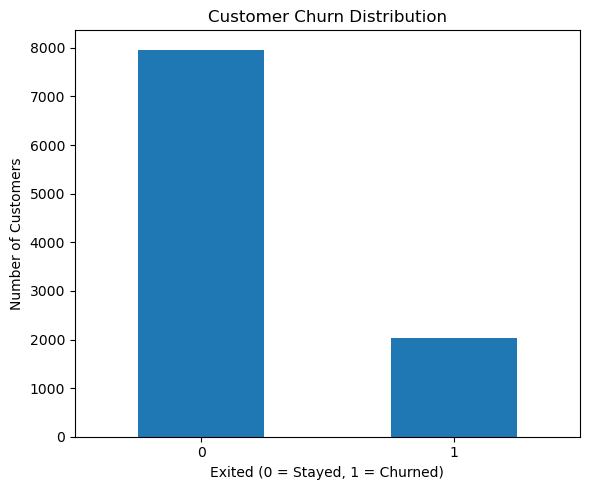

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("Churn_Modelling.csv")

print("Dataset Shape:")
print(df.shape)

print("\nColumns:")
print(df.columns.tolist())

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDuplicate Rows:")
print(df.duplicated().sum())

print("\nChurn Distribution:")
print(df["Exited"].value_counts())

print("\nChurn Percentage:")
print(
    df["Exited"]
    .value_counts(normalize=True)
    .mul(100)
)

print("\nFirst 5 Rows:")
print(df.head())


# Churn distribution
plt.figure(figsize=(6, 5))

df["Exited"].value_counts().plot(kind="bar")

plt.title("Customer Churn Distribution")
plt.xlabel("Exited (0 = Stayed, 1 = Churned)")
plt.ylabel("Number of Customers")
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

Dataset Shape:
(10000, 14)

Columns:
['RowNumber', 'CustomerId', 'Surname', 'CreditScore', 'Geography', 'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary', 'Exited']

Missing Values:
RowNumber          0
CustomerId         0
Surname            0
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64

Duplicate Rows:
0

Churn Distribution:
Exited
0    7963
1    2037
Name: count, dtype: int64

Churn Percentage:
Exited
0    79.63
1    20.37
Name: proportion, dtype: float64

First 5 Rows:
   RowNumber  CustomerId   Surname  CreditScore Geography  Gender  Age  \
0          1    15634602  Hargrave          619    France  Female   42   
1          2    15647311      Hill          608     Spain  Female   41   
2          3    15619304      Onio          50

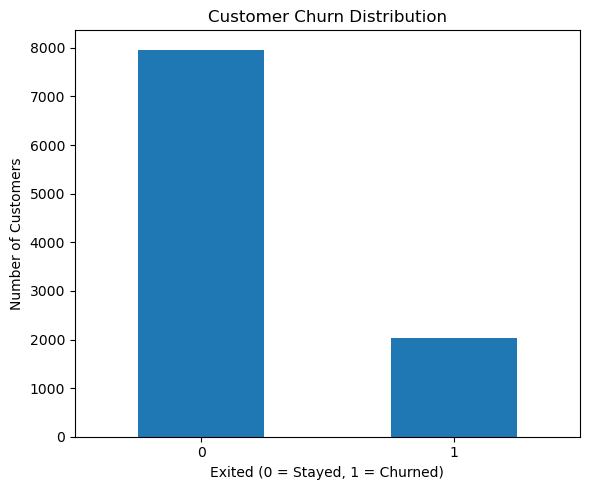

In [3]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("Churn_Modelling.csv")

print("Dataset Shape:")
print(df.shape)

print("\nColumns:")
print(df.columns.tolist())

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDuplicate Rows:")
print(df.duplicated().sum())

print("\nChurn Distribution:")
print(df["Exited"].value_counts())

print("\nChurn Percentage:")
print(
    df["Exited"]
    .value_counts(normalize=True)
    .mul(100)
)

print("\nFirst 5 Rows:")
print(df.head())

plt.figure(figsize=(6, 5))
df["Exited"].value_counts().plot(kind="bar")
plt.title("Customer Churn Distribution")
plt.xlabel("Exited (0 = Stayed, 1 = Churned)")
plt.ylabel("Number of Customers")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [4]:
print("\nChurn by Geography:")
print(
    pd.crosstab(
        df["Geography"],
        df["Exited"],
        normalize="index"
    ) * 100
)

print("\nChurn by Gender:")
print(
    pd.crosstab(
        df["Gender"],
        df["Exited"],
        normalize="index"
    ) * 100
)

print("\nChurn by Active Membership:")
print(
    pd.crosstab(
        df["IsActiveMember"],
        df["Exited"],
        normalize="index"
    ) * 100
)

print("\nAverage values by churn status:")
print(
    df.groupby("Exited")[
        [
            "CreditScore",
            "Age",
            "Tenure",
            "Balance",
            "NumOfProducts",
            "EstimatedSalary"
        ]
    ].mean()
)

X = df.drop(
    columns=[
        "RowNumber",
        "CustomerId",
        "Surname",
        "Exited"
    ]
)

y = df["Exited"]

print("\nX Shape:", X.shape)
print("y Shape:", y.shape)


Churn by Geography:
Exited             0          1
Geography                      
France     83.845233  16.154767
Germany    67.556796  32.443204
Spain      83.326605  16.673395

Churn by Gender:
Exited          0          1
Gender                      
Female  74.928461  25.071539
Male    83.544072  16.455928

Churn by Active Membership:
Exited                  0          1
IsActiveMember                      
0               73.149103  26.850897
1               85.730926  14.269074

Average values by churn status:
        CreditScore        Age    Tenure       Balance  NumOfProducts  \
Exited                                                                  
0        651.853196  37.408389  5.033279  72745.296779       1.544267   
1        645.351497  44.837997  4.932744  91108.539337       1.475209   

        EstimatedSalary  
Exited                   
0          99738.391772  
1         101465.677531  

X Shape: (10000, 10)
y Shape: (10000,)


In [5]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

categorical_features = [
    "Geography",
    "Gender"
]

numerical_features = [
    "CreditScore",
    "Age",
    "Tenure",
    "Balance",
    "NumOfProducts",
    "HasCrCard",
    "IsActiveMember",
    "EstimatedSalary"
]

X_train, X_valid, y_train, y_valid = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

preprocessor = ColumnTransformer(
    transformers=[
        (
            "numerical",
            StandardScaler(),
            numerical_features
        ),
        (
            "categorical",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_features
        )
    ]
)

logistic_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "classifier",
            LogisticRegression(
                max_iter=1000,
                class_weight="balanced"
            )
        )
    ]
)

logistic_model.fit(X_train, y_train)

lr_pred = logistic_model.predict(X_valid)
lr_prob = logistic_model.predict_proba(X_valid)[:, 1]

print("\nLOGISTIC REGRESSION")
print("Accuracy:", accuracy_score(y_valid, lr_pred))
print("Precision:", precision_score(y_valid, lr_pred, zero_division=0))
print("Recall:", recall_score(y_valid, lr_pred, zero_division=0))
print("F1:", f1_score(y_valid, lr_pred, zero_division=0))
print("ROC-AUC:", roc_auc_score(y_valid, lr_prob))


random_forest_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "classifier",
            RandomForestClassifier(
                n_estimators=200,
                random_state=42,
                class_weight="balanced",
                n_jobs=-1
            )
        )
    ]
)

random_forest_model.fit(X_train, y_train)

rf_pred = random_forest_model.predict(X_valid)
rf_prob = random_forest_model.predict_proba(X_valid)[:, 1]

print("\nRANDOM FOREST")
print("Accuracy:", accuracy_score(y_valid, rf_pred))
print("Precision:", precision_score(y_valid, rf_pred, zero_division=0))
print("Recall:", recall_score(y_valid, rf_pred, zero_division=0))
print("F1:", f1_score(y_valid, rf_pred, zero_division=0))
print("ROC-AUC:", roc_auc_score(y_valid, rf_prob))


gradient_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "classifier",
            GradientBoostingClassifier(
                n_estimators=100,
                random_state=42
            )
        )
    ]
)

gradient_model.fit(X_train, y_train)

gb_pred = gradient_model.predict(X_valid)
gb_prob = gradient_model.predict_proba(X_valid)[:, 1]

print("\nGRADIENT BOOSTING")
print("Accuracy:", accuracy_score(y_valid, gb_pred))
print("Precision:", precision_score(y_valid, gb_pred, zero_division=0))
print("Recall:", recall_score(y_valid, gb_pred, zero_division=0))
print("F1:", f1_score(y_valid, gb_pred, zero_division=0))
print("ROC-AUC:", roc_auc_score(y_valid, gb_prob))


LOGISTIC REGRESSION
Accuracy: 0.7135
Precision: 0.38722826086956524
Recall: 0.7002457002457002
F1: 0.49868766404199477
ROC-AUC: 0.7771654551315569

RANDOM FOREST
Accuracy: 0.8595
Precision: 0.771551724137931
Recall: 0.4398034398034398
F1: 0.5602503912363067
ROC-AUC: 0.8524795982423101

GRADIENT BOOSTING
Accuracy: 0.869
Precision: 0.7821011673151751
Recall: 0.49385749385749383
F1: 0.6054216867469879
ROC-AUC: 0.8702176753024209


In [6]:
from sklearn.metrics import classification_report, confusion_matrix

results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest",
        "Gradient Boosting"
    ],
    "Accuracy": [
        accuracy_score(y_valid, lr_pred),
        accuracy_score(y_valid, rf_pred),
        accuracy_score(y_valid, gb_pred)
    ],
    "Precision": [
        precision_score(y_valid, lr_pred, zero_division=0),
        precision_score(y_valid, rf_pred, zero_division=0),
        precision_score(y_valid, gb_pred, zero_division=0)
    ],
    "Recall": [
        recall_score(y_valid, lr_pred, zero_division=0),
        recall_score(y_valid, rf_pred, zero_division=0),
        recall_score(y_valid, gb_pred, zero_division=0)
    ],
    "F1": [
        f1_score(y_valid, lr_pred, zero_division=0),
        f1_score(y_valid, rf_pred, zero_division=0),
        f1_score(y_valid, gb_pred, zero_division=0)
    ],
    "ROC-AUC": [
        roc_auc_score(y_valid, lr_prob),
        roc_auc_score(y_valid, rf_prob),
        roc_auc_score(y_valid, gb_prob)
    ]
})

print("\nMODEL COMPARISON")
print(results.round(4))

best_model_name = results.loc[
    results["F1"].idxmax(),
    "Model"
]

print("\nBest model based on F1:", best_model_name)

if best_model_name == "Logistic Regression":
    best_predictions = lr_pred
elif best_model_name == "Random Forest":
    best_predictions = rf_pred
else:
    best_predictions = gb_pred

print("\nCONFUSION MATRIX")
print(confusion_matrix(y_valid, best_predictions))

print("\nCLASSIFICATION REPORT")
print(
    classification_report(
        y_valid,
        best_predictions,
        zero_division=0
    )
)


MODEL COMPARISON
                 Model  Accuracy  Precision  Recall      F1  ROC-AUC
0  Logistic Regression    0.7135     0.3872  0.7002  0.4987   0.7772
1        Random Forest    0.8595     0.7716  0.4398  0.5603   0.8525
2    Gradient Boosting    0.8690     0.7821  0.4939  0.6054   0.8702

Best model based on F1: Gradient Boosting

CONFUSION MATRIX
[[1537   56]
 [ 206  201]]

CLASSIFICATION REPORT
              precision    recall  f1-score   support

           0       0.88      0.96      0.92      1593
           1       0.78      0.49      0.61       407

    accuracy                           0.87      2000
   macro avg       0.83      0.73      0.76      2000
weighted avg       0.86      0.87      0.86      2000



In [7]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix
)

results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest",
        "Gradient Boosting"
    ],
    "Accuracy": [
        accuracy_score(y_valid, lr_pred),
        accuracy_score(y_valid, rf_pred),
        accuracy_score(y_valid, gb_pred)
    ],
    "Precision": [
        precision_score(y_valid, lr_pred, zero_division=0),
        precision_score(y_valid, rf_pred, zero_division=0),
        precision_score(y_valid, gb_pred, zero_division=0)
    ],
    "Recall": [
        recall_score(y_valid, lr_pred, zero_division=0),
        recall_score(y_valid, rf_pred, zero_division=0),
        recall_score(y_valid, gb_pred, zero_division=0)
    ],
    "F1": [
        f1_score(y_valid, lr_pred, zero_division=0),
        f1_score(y_valid, rf_pred, zero_division=0),
        f1_score(y_valid, gb_pred, zero_division=0)
    ],
    "ROC-AUC": [
        roc_auc_score(y_valid, lr_prob),
        roc_auc_score(y_valid, rf_prob),
        roc_auc_score(y_valid, gb_prob)
    ]
})

print("MODEL COMPARISON")
print(results.round(4))

best_model_name = results.loc[
    results["F1"].idxmax(),
    "Model"
]

print("\nBest model based on F1:", best_model_name)

if best_model_name == "Logistic Regression":
    best_model = logistic_model
    best_predictions = lr_pred

elif best_model_name == "Random Forest":
    best_model = random_forest_model
    best_predictions = rf_pred

else:
    best_model = gradient_model
    best_predictions = gb_pred

print("\nCONFUSION MATRIX")
print(confusion_matrix(y_valid, best_predictions))

print("\nCLASSIFICATION REPORT")
print(
    classification_report(
        y_valid,
        best_predictions,
        zero_division=0
    )
)

MODEL COMPARISON
                 Model  Accuracy  Precision  Recall      F1  ROC-AUC
0  Logistic Regression    0.7135     0.3872  0.7002  0.4987   0.7772
1        Random Forest    0.8595     0.7716  0.4398  0.5603   0.8525
2    Gradient Boosting    0.8690     0.7821  0.4939  0.6054   0.8702

Best model based on F1: Gradient Boosting

CONFUSION MATRIX
[[1537   56]
 [ 206  201]]

CLASSIFICATION REPORT
              precision    recall  f1-score   support

           0       0.88      0.96      0.92      1593
           1       0.78      0.49      0.61       407

    accuracy                           0.87      2000
   macro avg       0.83      0.73      0.76      2000
weighted avg       0.86      0.87      0.86      2000



In [8]:
import joblib

joblib.dump(
    gradient_model,
    "customer_churn_pipeline.pkl"
)

print("Customer churn pipeline saved successfully.")

Customer churn pipeline saved successfully.


In [9]:
import os

print(os.path.exists("customer_churn_pipeline.pkl"))

True
